Class order used by LabelEncoder: ['High', 'Low', 'Moderate', 'Severe']

Training: LogisticRegression
Accuracy: 0.9857


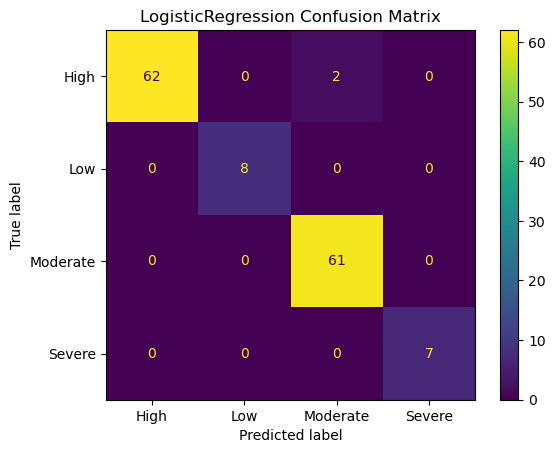


Training: RandomForest
Accuracy: 0.9000


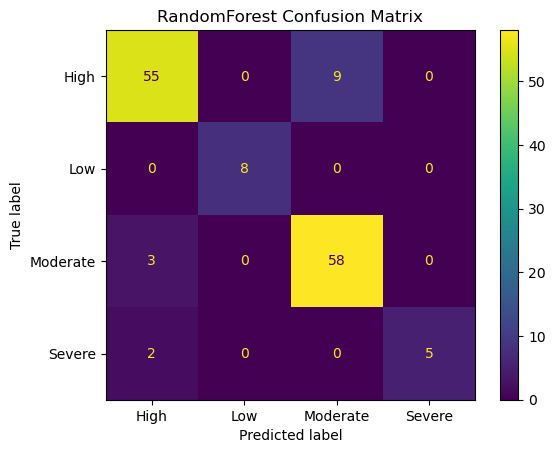


Training: GradientBoosting
Accuracy: 0.9000


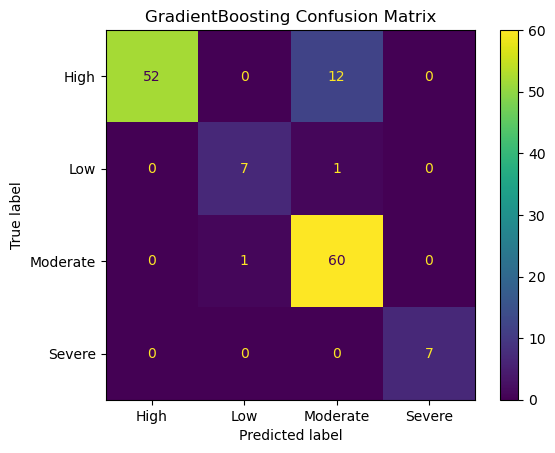


Training: SVM
Accuracy: 0.9714


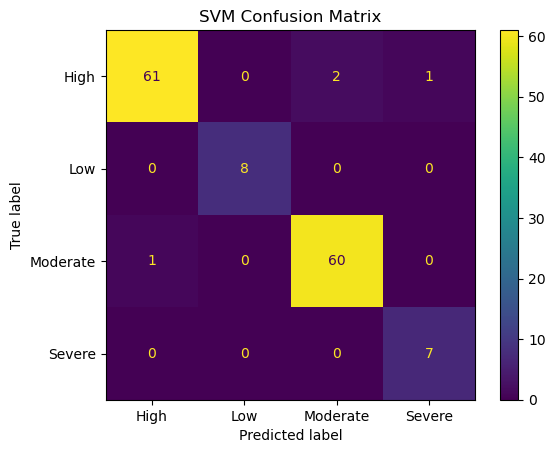

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import joblib

# Step 1: Load labeled data
df = pd.read_csv('../../data/MentalParameter_labeled.csv')

# Step 2: Define feature columns
features = [
    "Perceived Control",
    "Stress Frequency and Intensity (Weight: 15%)",
    "Emotional Regulation",
    "Physical Symptoms of Stress",
    "Cognitive Stress (Negative Self-Thoughts)",
    "Behavioral Response",
    "Work-Related Stress Factors (Weight: 10%)",
    "Concentration and Productivity (Weight: 10%)",
    "Suicidal Thoughts (Optional, Use with Caution)",
    "Available Time Normalized"
]

# Step 3: Prepare data
X = df[features].fillna(df[features].mean())
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Stress_Level"])

print("Class order used by LabelEncoder:", list(label_encoder.classes_))

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Define models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True)
}

# Step 6: Train and evaluate
best_model = None
best_score = 0

for name, model in models.items():
    print(f"\nTraining: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {score:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    if score > best_score:
        best_score = score
        best_model = model

